# 🇲🇦 Analyse de Sentiments – Darija (Positif / Négatif)
## Pipeline Corrigé : EDA → Preprocessing → ML → DL (Séquences) → Transformers

| Pipeline | Embeddings | Modèles |
|----------|-----------|---------|
| **A – ML Classiques** | TF-IDF | SVM · Logistic Regression · Random Forest · Naive Bayes |
| **B – Deep Learning** | Word2Vec + **Embedding Layer** (séquences) | BiLSTM · LSTM simple · CNN+LSTM |
| **C – Transformers** | DarijaBERT · DarijaBERT-arabizi · AraBERT | Fine-tuning |

### ✅ Corrections appliquées :
1. 🔴 **DL** : Embedding Layer + séquences d'index (plus de mean pooling)
2. 🟠 **Split** : Un seul split sur les index → appliqué à toutes les features
3. 🟡 **Stop words** : Encodage robuste avec fallback automatique
4. 🟡 **Arabizi** : Stratégie cohérente — Latin pour arabizi-BERT, Arabe pour DarijaBERT
5. 🟢 **Architectures DL** : LSTM simple · BiLSTM · CNN+LSTM


# 0. Installation et Imports

In [ ]:
!pip install transformers datasets torch gensim imbalanced-learn emoji -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 24.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re, os, warnings
import matplotlib.pyplot as plt
from collections import Counter

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device : {device}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
else:
    print("  ⚠ Pas de GPU — aller dans Runtime > Changer le type d'exécution > GPU")


✓ Device : cuda
  GPU : Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH  = "/content/drive/MyDrive/analyse_de_sentiments"
SAVE_PATH  = "/content/drive/MyDrive/analyse_sentiment2"
os.makedirs(SAVE_PATH, exist_ok=True)

files = {
    "moroccan_dialectal":  os.path.join(BASE_PATH, "Moroccan_Dialectal_Reviews_dataset.csv"),
    "afrisenti":           os.path.join(BASE_PATH, "afrisenti-semeval_morrocan.csv"),
    "sans_standard":       os.path.join(BASE_PATH, "dataset_sans_standard.csv"),
    "hugging_face":        os.path.join(BASE_PATH, "hugging_face_review_label.csv"),
    "data_cleaned":        os.path.join(BASE_PATH, "DATA_CLEANED.csv"),
    "ElecMorocco2016_mda": os.path.join(BASE_PATH, "ElecMorocco2016_mda_.csv"),
}
print("✓ Chemins définis")


Mounted at /content/drive
✓ Chemins définis


# 1. Exploration des Données (EDA)

In [ ]:
def eda_light(file_path):
    print("=" * 70)
    print(f"Fichier : {os.path.basename(file_path)}")
    print("=" * 70)
    df = pd.read_csv(file_path)
    print("Shape :", df.shape)
    print("Colonnes :", df.columns.tolist())
    print(df.head(3))
    text_col = next((c for c in df.columns if df[c].dtype == "object"), None)
    print("Colonne texte détectée :", text_col)
    return df, text_col

results = {}
for nom, path in files.items():
    df_temp, col_texte = eda_light(path)
    results[nom] = {"df": df_temp, "text_col": col_texte}
    print()


Fichier : Moroccan_Dialectal_Reviews_dataset.csv
Shape : (600, 4)
Colonnes : ['Text', 'product', 'sentiment', 'Class']
                                                                        Text  \
0                        ماكينة عجباتني كاتحيد شعر من الجدر ومكاتخليش لاطراس   
1                        واعرة كاتشد الشارج لمدة طويلة وساهلة فالخدمة ديالها   
2  زوينة وصغيرة ومطيورة كيما كايقولو هههه، فلوسها حلال زوينة وعملية شكرا لكم   

        product sentiment  Class  
0  hair trimmer  Positive      1  
1  hair trimmer  Positive      1  
2  hair trimmer  Positive      1  
Colonne texte détectée : Text

Fichier : afrisenti-semeval_morrocan.csv
Shape : (6998, 2)
Colonnes : ['commentaire', 'sentiment']
                                                                       commentaire  \
0  #nada0074 Jomo3a mobaraka inchallah 3liya we 3la la famille dyali awalan 9ab...   
1  @nohita123 @Anyssa_Ch la daba homa li ghadi ykhtaro hna khas nsd3ohom b smit...   
2           @sansuuna matbkhlich

# 2. Détection du Script (Arabe / Latin / Mixte)

In [ ]:
def detect_script(text):
    if pd.isna(text): return "unknown"
    text = str(text)
    has_arabic = bool(re.search(r'[\u0600-\u06FF]', text))
    has_latin  = bool(re.search(r'[a-zA-Z]', text))
    if has_arabic and not has_latin:   return "darija_ar"
    elif has_latin and not has_arabic: return "latin"
    elif has_arabic and has_latin:     return "mix"
    else:                              return "unknown"

for nom, data in results.items():
    print(f"\n{'='*55}\n DATASET : {nom}\n{'='*55}")
    df = data["df"]
    df["script_type"] = df[data["text_col"]].apply(detect_script)
    print(df["script_type"].value_counts())



 DATASET : moroccan_dialectal
script_type
darija_ar    591
mix            9
Name: count, dtype: int64

 DATASET : afrisenti
script_type
latin    6809
mix       189
Name: count, dtype: int64

 DATASET : sans_standard
script_type
darija_ar    5470
unknown         6
Name: count, dtype: int64

 DATASET : hugging_face
script_type
darija_ar    573
latin        218
mix           60
Name: count, dtype: int64

 DATASET : data_cleaned
script_type
darija_ar    13125
latin         4579
mix           1527
unknown        760
Name: count, dtype: int64

 DATASET : ElecMorocco2016_mda
script_type
darija_ar    3716
mix           179
Name: count, dtype: int64


# 3. Distribution des Labels par Dataset

In [ ]:
def afficher_distribution(df, col_label, nom):
    print(f"{'='*55}\n {nom}\n{'='*55}")
    print(f"  Valeurs : {df[col_label].unique().tolist()}")
    print(df[col_label].value_counts().to_string())
    print()

df1 = pd.read_csv(files["moroccan_dialectal"])
afficher_distribution(df1, "sentiment", "Moroccan Dialectal Reviews")
df2 = pd.read_csv(files["afrisenti"])
afficher_distribution(df2, "sentiment", "AfriSenti SemEval")
df3 = pd.read_csv(files["sans_standard"])
afficher_distribution(df3, "type", "Dataset sans standard")
df4 = pd.read_csv(files["hugging_face"])
afficher_distribution(df4, "label", "Hugging Face Reviews")
df5 = pd.read_csv(files["data_cleaned"])
afficher_distribution(df5, "polarity", "DATA_CLEANED")
df6 = pd.read_csv(files["ElecMorocco2016_mda"])
afficher_distribution(df6, "sentiment", "ElecMorocco2016_mda")


 Moroccan Dialectal Reviews
  Valeurs : ['Positive', 'Negative']
sentiment
Positive    325
Negative    275

 AfriSenti SemEval
  Valeurs : ['Positive', 'Neutral', 'Negative', nan]
sentiment
Neutral     2919
Negative    1639
Positive    1490

 Dataset sans standard
  Valeurs : ['neutral', 'positive', 'negative', 'mixed']
type
positive    2997
neutral     1311
negative     985
mixed        183

 Hugging Face Reviews
  Valeurs : ['negative', 'neutral', 'positive', 'negative ']
label
positive     456
negative     269
neutral      122
negative       4

 DATA_CLEANED
  Valeurs : [1, -1]
polarity
 1    9999
-1    9992

 ElecMorocco2016_mda
  Valeurs : ['N', 'P']
sentiment
N    2632
P    1263



# 4. Fusion des Datasets — Binaire (Positive / Negative)

In [ ]:
print("="*60 + "\nFUSION — Positif / Négatif seulement\n" + "="*60)

tous = []

df1 = pd.read_csv(files["moroccan_dialectal"])
d = pd.DataFrame({"texte": df1["Text"],
                  "label": df1["sentiment"].str.strip().str.capitalize()})
tous.append(d); print(f"1. Moroccan Dialectal      : {len(d)} lignes")

df2 = pd.read_csv(files["afrisenti"])
d = pd.DataFrame({"texte": df2["commentaire"],
                  "label": df2["sentiment"].str.strip().str.capitalize()})
d = d.dropna(subset=["label"])
tous.append(d); print(f"2. AfriSenti               : {len(d)} lignes")

df3 = pd.read_csv(files["sans_standard"])
d = pd.DataFrame({"texte": df3["tweets"],
                  "label": df3["type"].str.strip().str.capitalize()})
d = d[d["label"].isin(["Positive", "Negative"])]
tous.append(d); print(f"3. Sans standard           : {len(d)} lignes")

df4 = pd.read_csv(files["hugging_face"])
d = pd.DataFrame({"texte": df4["review"],
                  "label": df4["label"].str.strip().str.capitalize()})
tous.append(d); print(f"4. Hugging Face            : {len(d)} lignes")

df5 = pd.read_csv(files["data_cleaned"])
d = pd.DataFrame({"texte": df5["sentence"],
                  "label": df5["polarity"].map({1: "Positive", -1: "Negative"})})
d = d.dropna(subset=["label"])
tous.append(d); print(f"5. DATA_CLEANED            : {len(d)} lignes")

df6 = pd.read_csv(files["ElecMorocco2016_mda"])
d = pd.DataFrame({"texte": df6["comment_message"],
                  "label": df6["sentiment"].map({"P": "Positive", "N": "Negative"})})
d = d.dropna(subset=["label"])
tous.append(d); print(f"6. ElecMorocco2016         : {len(d)} lignes")

dataset_final = pd.concat(tous, ignore_index=True)
dataset_final = dataset_final.dropna()
dataset_final["texte"] = dataset_final["texte"].astype(str)
dataset_final["label"] = dataset_final["label"].astype(str).str.strip().str.capitalize()
dataset_final = dataset_final[
    dataset_final["label"].isin(["Positive", "Negative"])
].reset_index(drop=True)

print(f"\n{'='*60}\nRÉSULTAT FUSION\n{'='*60}")
print("Total :", len(dataset_final))
print(dataset_final["label"].value_counts())
dataset_final.to_csv("dataset_fusionner.csv", index=False, encoding="utf-8-sig")
print("\n✓ Sauvegardé : dataset_fusionner.csv")


FUSION — Positif / Négatif seulement
1. Moroccan Dialectal      : 600 lignes
2. AfriSenti               : 6048 lignes
3. Sans standard           : 3982 lignes
4. Hugging Face            : 851 lignes
5. DATA_CLEANED            : 19991 lignes
6. ElecMorocco2016         : 3895 lignes

RÉSULTAT FUSION
Total : 32323
label
Positive    16527
Negative    15796
Name: count, dtype: int64

✓ Sauvegardé : dataset_fusionner.csv


# 5. Preprocessing
## Pipeline de nettoyage :
```
Raw Text
  ↓ Clean Web Noise (URLs, mentions, HTML)
  ↓ Emoji Processing  (😍→EMO_POS  😡→EMO_NEG)
  ↓ Normalize Repeated Chars  (زووووين→زوين)
  ↓ [selon pipeline] Arabizi Conversion  (7→ح / gardé latin)
  ↓ Remove Diacritics + Normalize Arabic
  ↓ Remove Numbers + Clean Punctuation
  ↓ Validate (min 2 tokens)
```


## 5a. Emoji Processing

In [ ]:
EMOJI_POSITIF = {
    '😍','🥰','😊','😀','😃','😄','😁','🤩','😇','🙂',
    '❤','❤️','💕','💖','💗','💓','💞','💚','💛','💙','💜','🤍','🧡',
    '👍','👌','🤗','💯','✅','🏆','⭐','🌟','✨','🎉','🎊',
    '🌹','💐','🌺','🌸','🙏','🌝',
}
EMOJI_NEGATIF = {
    '😡','🤬','😠','😤','👎','🖕',
    '😢','😭','😞','😔','😣','😖','😩','😫','😥','😓','😒',
    '🤢','🤮','💔','☠','💀','⛔','🚫','❌','🙅',
    '😑','😶','🙄','😬','😰','😨',
}

_EMOJI_RE = re.compile(
    "[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF"
    "\U00002702-\U000027B0\U000024C2-\U0001F251"
    "\U0001f926-\U0001f937\U00010000-\U0010ffff"
    "\u2640-\u2642\u2600-\u2B55\u200d\u23cf"
    "\u23e9\u231a\ufe0f\u3030]+",
    flags=re.UNICODE
)

def convert_emojis(text):
    text = str(text)
    for e in EMOJI_POSITIF: text = text.replace(e, ' EMO_POS ')
    for e in EMOJI_NEGATIF: text = text.replace(e, ' EMO_NEG ')
    text = _EMOJI_RE.sub('', text)
    return re.sub(r'\s+', ' ', text).strip()

# Test
print("Test emoji :")
print(convert_emojis("هذا المنتج 😍💕 زوين ! لكن التوصيل 😡👎 كاين مشكل"))


Test emoji :
هذا المنتج EMO_POS EMO_POS زوين ! لكن التوصيل EMO_NEG EMO_NEG كاين مشكل


## 5b. Arabizi Conversion — Stratégie Cohérente

> ✅ **Correction #4** : deux fonctions séparées selon le modèle cible
> - `convert_arabizi_to_arabic()` → pour **DarijaBERT** (script arabe)
> - Texte brut gardé → pour **DarijaBERT-arabizi** (comprend 7, 3, 9 en contexte latin)


In [ ]:
# ── Arabizi → Arabe (pour DarijaBERT & ML/DL)  ──────────────────────────────
ARABIZI_MAP = {
    '7': 'ح', '3': 'ع', '9': 'ق',
    '2': 'أ', '5': 'خ', '8': 'غ',
}

def convert_arabizi_to_arabic(text):
    """
    Convertit les chiffres arabizi → lettres arabes.
    Uniquement dans les mots contenant aussi des lettres.
    Exemples : 7rib→حrib  |  3lash→علash  |  9raya→قraya
    """
    text = str(text)
    words = text.split()
    result = []
    for word in words:
        has_letter = bool(re.search(r'[a-zA-Z\u0600-\u06FF]', word))
        has_arabizi = bool(re.search(r'[235689]', word))
        if has_letter and has_arabizi:
            for digit, arabic_letter in ARABIZI_MAP.items():
                word = word.replace(digit, arabic_letter)
        result.append(word)
    return ' '.join(result)

# Test
print("Test arabizi → arabe :")
print(convert_arabizi_to_arabic("7rib weld 3lash dyal 9raya mzyan"))
print(convert_arabizi_to_arabic("ana bkhir 3ndek 5bar"))


Test arabizi → arabe :
7rib weld عlash dyal قraya mzyan
ana bkhir عndek خbar


## 5c. Fonctions de Normalisation

In [ ]:
def clean_web_noise(text):
    text = str(text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[\u200c\u200d\uFEFF]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def normalize_repeated_chars(text):
    """زووووين → زوين  |  waaaaw → waw"""
    text = str(text)
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1', text)
    text = re.sub(r'([\u0600-\u06FF])\1{2,}', r'\1', text)
    return text

def remove_repeated_words(text):
    return re.sub(r'\b(\w+)( \1\b)+', r'\1', str(text))

def remove_diacritics(text):
    return re.sub(r'[\u064B-\u0652\u0670\uFE70-\uFEFF]', '', str(text))

def normalize_arabic(text):
    text = str(text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    return re.sub(r'ـ+', '', text)

def clean_punctuation_numbers(text):
    text = str(text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[()\[\]{}<>\"\'~`;,:#@%&*\-+/=\\]', ' ', text)
    text = re.sub(r'!{2,}', '!', text)
    text = re.sub(r'\?{2,}', '?', text)
    text = re.sub(r'\.{2,}', '.', text)
    return re.sub(r'\s+', ' ', text).strip()

def is_valid_text(text):
    if pd.isna(text): return False
    return len(str(text).strip().split()) >= 2

print("✓ Fonctions de normalisation définies")


✓ Fonctions de normalisation définies


## 5d. Trois Pipelines de Preprocessing

| Pipeline | Pour | Arabizi |
|----------|------|---------|
| `preprocess_ml_dl` | ML classiques + Deep Learning | Converti → Arabe |
| `preprocess_darija_bert` | DarijaBERT (script arabe) | Converti → Arabe |
| `preprocess_arabizi_bert` | DarijaBERT-arabizi (script latin) | **Gardé** (7, 3, 9) |


In [ ]:
# ── Pipeline ML + DL + DarijaBERT (script arabe) ─────────────────────────────
def preprocess_ml_dl(text):
    """Preprocessing complet : arabizi → arabe + normalisation totale."""
    text = clean_web_noise(text)
    text = convert_emojis(text)
    text = convert_arabizi_to_arabic(text)   # 7→ح, 3→ع
    text = normalize_repeated_chars(text)
    text = remove_diacritics(text)
    text = normalize_arabic(text)
    text = remove_repeated_words(text)
    text = clean_punctuation_numbers(text)
    return re.sub(r'\s+', ' ', text).strip()

# ── Pipeline DarijaBERT-arabizi (garde les chiffres arabizi en latin) ─────────
def preprocess_arabizi_bert(text):
    """
    Preprocessing minimal — NE CONVERTIT PAS l'arabizi.
    DarijaBERT-arabizi comprend nativement 7, 3, 9 en contexte latin.
    """
    text = clean_web_noise(text)
    text = convert_emojis(text)
    text = normalize_repeated_chars(text)   # زووووين → زوين, waaaaw → waw
    return re.sub(r'\s+', ' ', text).strip()

# ── Test comparatif ───────────────────────────────────────────────────────────
ex = "هذا المنتج 😍 زووووين بزاف! 7sab 3ndek كاين مشكل 😡"
print(f"Original              : {ex}")
print(f"ML / DL / DarijaBERT : {preprocess_ml_dl(ex)}")
print(f"DarijaBERT-arabizi   : {preprocess_arabizi_bert(ex)}")


Original              : هذا المنتج 😍 زووووين بزاف! 7sab 3ndek كاين مشكل 😡
ML / DL / DarijaBERT : هذا المنتج EMO_POS زوين بزاف! sab عndek كاين مشكل EMO_NEG
DarijaBERT-arabizi   : هذا المنتج EMO_POS زوين بزاف! 7sab 3ndek كاين مشكل EMO_NEG


# 6. Application du Preprocessing + Déduplication

In [ ]:
df = pd.read_csv("dataset_fusionner.csv")
print("Shape initiale :", df.shape)

print("\nApplication preprocessing ML/DL...")
df["texte_ml"]      = df["texte"].apply(preprocess_ml_dl)

print("Application preprocessing arabizi-BERT...")
df["texte_ar_bert"] = df["texte"].apply(preprocess_arabizi_bert)

# Validation
df = df[df["texte_ml"].apply(is_valid_text)].copy()
df = df[df["texte_ar_bert"].apply(is_valid_text)].copy()

# Déduplication sur texte_ml
cle   = df["texte_ml"].astype(str).str.strip().str.lower()
avant = len(df)
df    = df[~cle.duplicated(keep="first")].reset_index(drop=True)
print(f"\nDoublons supprimés : {avant - len(df)}  ({avant} → {len(df)})")

# Shuffle avec seed fixe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 Dataset final : {len(df)} lignes")
print(df["label"].value_counts())

df.to_csv("dataset_clean.csv", index=False, encoding="utf-8-sig")
print("\n✓ Sauvegardé : dataset_clean.csv")


Shape initiale : (32323, 2)

Application preprocessing ML/DL...
Application preprocessing arabizi-BERT...

Doublons supprimés : 2565  (30945 → 28380)

📊 Dataset final : 28380 lignes
label
Negative    14227
Positive    14153
Name: count, dtype: int64

✓ Sauvegardé : dataset_clean.csv


# 7. Stop Words
> ✅ **Correction #3** : encodage robuste avec fallback automatique
> (utf-16 → utf-8-sig → utf-8 → latin-1)


In [ ]:
# ── Chargement robuste avec fallback ─────────────────────────────────────────
SW_PATH = os.path.join(SAVE_PATH, "Stop_words.csv")

stop_words_set = set()
encodings_to_try = ["utf-16", "utf-8-sig", "utf-8", "latin-1", "cp1256"]

for enc in encodings_to_try:
    try:
        sw_df = pd.read_csv(
            SW_PATH, encoding=enc, header=None,
            keep_default_na=False, dtype=str
        )
        raw_words = sw_df.iloc[:, 0].str.strip().tolist()
        raw_words = [w for w in raw_words if w and w != "nan"]
        if len(raw_words) > 10:
            stop_words_set = set(w.lower() for w in raw_words)
            print(f"✓ Stop words chargés avec encodage '{enc}'")
            print(f"  Mots uniques : {len(stop_words_set)}")
            # Vérification : afficher 5 mots
            print(f"  Exemples     : {list(stop_words_set)[:5]}")
            break
    except Exception as e:
        print(f"  '{enc}' échoué : {e}")

if not stop_words_set:
    print("⚠ Impossible de charger le fichier stop words → liste vide utilisée")
    stop_words_set = set()

# ── Application ───────────────────────────────────────────────────────────────
def remove_stop_words(text, sw):
    tokens = str(text).lower().split()
    return " ".join(w for w in tokens if w not in sw)

def tokenize(text):
    return str(text).strip().split()

df = pd.read_csv("dataset_clean.csv")
df["texte_ml"] = df["texte_ml"].apply(lambda x: remove_stop_words(x, stop_words_set))
df["tokens"]   = df["texte_ml"].apply(tokenize)
df = df[df["tokens"].apply(len) >= 2].reset_index(drop=True)

print(f"\nShape après stop words : {df.shape}")
print(df[["texte_ml", "tokens", "label"]].head(3))

df.to_csv("dataset_preprocessed.csv", index=False, encoding="utf-8-sig")
print("\n✓ Sauvegardé : dataset_preprocessed.csv")


  'utf-16' échoué : [Errno 2] No such file or directory: '/content/drive/MyDrive/analyse_sentiment2/Stop_words.csv'
  'utf-8-sig' échoué : [Errno 2] No such file or directory: '/content/drive/MyDrive/analyse_sentiment2/Stop_words.csv'
  'utf-8' échoué : [Errno 2] No such file or directory: '/content/drive/MyDrive/analyse_sentiment2/Stop_words.csv'
  'latin-1' échoué : [Errno 2] No such file or directory: '/content/drive/MyDrive/analyse_sentiment2/Stop_words.csv'
  'cp1256' échoué : [Errno 2] No such file or directory: '/content/drive/MyDrive/analyse_sentiment2/Stop_words.csv'
⚠ Impossible de charger le fichier stop words → liste vide utilisée

Shape après stop words : (28380, 5)
                                                             texte_ml  \
0  شكون هادو؟؟هالعار متبقاوش تجيبو هد نماذج كيخرجو علي الشباب emo_neg   
1                                      شكون لي شاف bts فالحيط emo_pos   
2                                                 لموت تدحوكات انا مت   

                   

# 8. Split Train / Val / Test — UN SEUL SPLIT SUR LES INDEX
> ✅ **Correction #2** : on split d'abord les **index** → puis on applique à toutes les matrices.
> Cela garantit que train/val/test sont exactement les mêmes exemples pour tous les pipelines.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

df = pd.read_csv("dataset_preprocessed.csv")
df["tokens"] = df["tokens"].apply(eval)   # convertir string → liste

le = LabelEncoder()
y  = le.fit_transform(df["label"])   # Negative=0, Positive=1
print("Classes :", le.classes_)
print("Labels  :", dict(zip(le.classes_, range(len(le.classes_)))))

N = len(df)

# ── ÉTAPE 1 : split des index uniquement ─────────────────────────────────────
idx = np.arange(N)

idx_trainval, idx_test = train_test_split(
    idx, test_size=0.20, random_state=42, stratify=y)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.20, random_state=42, stratify=y[idx_trainval])

print(f"\n{'='*55}")
print(f"SPLIT  64% train | 16% val | 20% test")
print(f"{'='*55}")
print(f"  Train : {len(idx_train)} exemples")
print(f"  Val   : {len(idx_val)} exemples")
print(f"  Test  : {len(idx_test)} exemples")
print(f"\n  Distribution train : {Counter(y[idx_train])}")
print(f"  Distribution val   : {Counter(y[idx_val])}")
print(f"  Distribution test  : {Counter(y[idx_test])}")

# Labels pour chaque split (utilisés par tous les modèles)
y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]

# class_weight (ML classiques + DL)
cw_arr  = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(cw_arr))
print(f"\n  class_weight : {class_weights_dict}")


Classes : ['Negative' 'Positive']
Labels  : {'Negative': 0, 'Positive': 1}

SPLIT  64% train | 16% val | 20% test
  Train : 18163 exemples
  Val   : 4541 exemples
  Test  : 5676 exemples

  Distribution train : Counter({np.int64(0): 9105, np.int64(1): 9058})
  Distribution val   : Counter({np.int64(0): 2277, np.int64(1): 2264})
  Distribution test  : Counter({np.int64(0): 2845, np.int64(1): 2831})

  class_weight : {0: np.float64(0.9974190005491488), 1: np.float64(1.0025943916979465)}


# 9. Feature Extraction
## 9a. TF-IDF *(Pipeline A – ML Classiques)*

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

textes_ml = df["texte_ml"].tolist()

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)
X_tfidf_all = tfidf.fit_transform(textes_ml)

# ── ÉTAPE 2 : appliquer les index sur TF-IDF ──────────────────────────────────
X_train_tfidf = X_tfidf_all[idx_train]
X_val_tfidf   = X_tfidf_all[idx_val]
X_test_tfidf  = X_tfidf_all[idx_test]

print(f"✓ TF-IDF total   : {X_tfidf_all.shape}")
print(f"  Train TF-IDF   : {X_train_tfidf.shape}")
print(f"  Val   TF-IDF   : {X_val_tfidf.shape}")
print(f"  Test  TF-IDF   : {X_test_tfidf.shape}")


✓ TF-IDF total   : (28380, 10000)
  Train TF-IDF   : (18163, 10000)
  Val   TF-IDF   : (4541, 10000)
  Test  TF-IDF   : (5676, 10000)


## 9b. Word2Vec + Vocabulaire + Séquences *(Pipeline B – Deep Learning)*

> ✅ **Correction #1** : au lieu de la moyenne des vecteurs (mean pooling),
> on construit un vocabulaire, on convertit chaque texte en **séquence d'index entiers**,
> on **padde** à longueur fixe, puis l'Embedding Layer apprend / utilise les poids Word2Vec.
> Cela permet à LSTM/CNN de traiter les dépendances temporelles correctement.


In [ ]:
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── 1. Entraîner Word2Vec sur TOUT le corpus (avant split) ───────────────────
EMBEDDING_DIM = 128
MAX_LEN       = 100   # longueur maximale des séquences

corpus_tokens = df["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=corpus_tokens,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=2,
    workers=4,
    sg=1,       # Skip-Gram
    epochs=15
)
print(f"✓ Word2Vec entraîné : {len(w2v_model.wv)} mots  (dim={EMBEDDING_DIM})")

# ── 2. Construire le vocabulaire → index ──────────────────────────────────────
# mot_inconnu = index 1, padding = index 0
word2idx = {"<PAD>": 0, "<UNK>": 1}
for word in w2v_model.wv.key_to_index:
    word2idx[word] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print(f"✓ Taille vocabulaire : {VOCAB_SIZE} (PAD=0, UNK=1)")

# ── 3. Convertir tokens → séquences d'index ───────────────────────────────────
def tokens_to_sequence(tokens):
    return [word2idx.get(w, 1) for w in tokens]   # 1 = <UNK>

sequences_all = [tokens_to_sequence(toks) for toks in corpus_tokens]

# ── 4. Padding (post-padding, post-truncating) ────────────────────────────────
X_seq_all = pad_sequences(
    sequences_all,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    value=0   # <PAD>
)
print(f"✓ Séquences paddées : {X_seq_all.shape}  (N × {MAX_LEN})")

# ── 5. Appliquer les index du split ───────────────────────────────────────────
X_train_seq = X_seq_all[idx_train]
X_val_seq   = X_seq_all[idx_val]
X_test_seq  = X_seq_all[idx_test]

print(f"  Train séq : {X_train_seq.shape}")
print(f"  Val   séq : {X_val_seq.shape}")
print(f"  Test  séq : {X_test_seq.shape}")


✓ Word2Vec entraîné : 24900 mots  (dim=128)
✓ Taille vocabulaire : 24902 (PAD=0, UNK=1)
✓ Séquences paddées : (28380, 100)  (N × 100)
  Train séq : (18163, 100)
  Val   séq : (4541, 100)
  Test  séq : (5676, 100)


In [ ]:
# ── 6. Matrice d'embedding initialisée avec Word2Vec ─────────────────────────
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

for word, idx_w in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx_w] = w2v_model.wv[word]
    # <PAD>=0 et <UNK>=1 restent à zéro (appris pendant l'entraînement)

print(f"✓ Matrice d'embedding : {embedding_matrix.shape}")
print(f"  Mots couverts : {sum(1 for w in word2idx if w in w2v_model.wv)}/{VOCAB_SIZE}")

# Sauvegarder Word2Vec
w2v_model.save(os.path.join(SAVE_PATH, "word2vec_darija.model"))
print("✓ Word2Vec sauvegardé")


✓ Matrice d'embedding : (24902, 128)
  Mots couverts : 24900/24902
✓ Word2Vec sauvegardé


# 10. Pipeline A – Modèles ML Classiques (TF-IDF)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

modeles_ml = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=1.0, class_weight="balanced", random_state=42),
    "LinearSVC": LinearSVC(
        C=1.0, max_iter=3000, class_weight="balanced", random_state=42),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        random_state=42, n_jobs=-1),
}

resultats = {}

print("="*65 + "\nENTRAÎNEMENT ML CLASSIQUES\n" + "="*65)
for nom, modele in modeles_ml.items():
    modele.fit(X_train_tfidf, y_train)
    yv = modele.predict(X_val_tfidf)
    yt = modele.predict(X_test_tfidf)
    acc_v = accuracy_score(y_val, yv);  f1_v = f1_score(y_val, yv, average="macro")
    acc_t = accuracy_score(y_test, yt); f1_t = f1_score(y_test, yt, average="macro")
    resultats[nom] = {"acc_val": acc_v, "f1_val": f1_v,
                      "acc_test": acc_t, "f1_test": f1_t}
    print(f"\n── {nom} ──")
    print(f"  Val  → Acc: {acc_v:.4f}  F1: {f1_v:.4f}")
    print(f"  Test → Acc: {acc_t:.4f}  F1: {f1_t:.4f}")
    print(classification_report(y_test, yt, target_names=le.classes_, digits=3))


ENTRAÎNEMENT ML CLASSIQUES

── Logistic Regression ──
  Val  → Acc: 0.8527  F1: 0.8526
  Test → Acc: 0.8539  F1: 0.8539
              precision    recall  f1-score   support

    Negative      0.859     0.848     0.853      2845
    Positive      0.849     0.860     0.855      2831

    accuracy                          0.854      5676
   macro avg      0.854     0.854     0.854      5676
weighted avg      0.854     0.854     0.854      5676


── LinearSVC ──
  Val  → Acc: 0.8436  F1: 0.8436
  Test → Acc: 0.8414  F1: 0.8414
              precision    recall  f1-score   support

    Negative      0.842     0.841     0.842      2845
    Positive      0.841     0.842     0.841      2831

    accuracy                          0.841      5676
   macro avg      0.841     0.841     0.841      5676
weighted avg      0.841     0.841     0.841      5676


── Naive Bayes ──
  Val  → Acc: 0.7961  F1: 0.7961
  Test → Acc: 0.7912  F1: 0.7912
              precision    recall  f1-score   support

   

# 11. Pipeline B – Deep Learning (Séquences + Embedding Layer)
> ✅ **Correction #1 + #5** : Architecture correcte + 3 architectures testées


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout,
    Conv1D, MaxPooling1D, GlobalMaxPooling1D,
    Input, concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def get_callbacks(patience_stop=8, patience_lr=4):
    return [
        EarlyStopping(
            monitor="val_loss", patience=patience_stop,
            restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=patience_lr, min_lr=1e-6, verbose=1),
    ]

def make_embedding_layer(vocab_size, embed_dim, embed_matrix, trainable=True):
    """
    Crée une couche Embedding initialisée avec les poids Word2Vec.
    trainable=True : fine-tune les embeddings pendant l'entraînement.
    """
    return Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embed_matrix],
        input_length=MAX_LEN,
        trainable=trainable,
        mask_zero=True,    # ignore le padding dans LSTM
        name="embedding"
    )

print(f"✓ Paramètres DL :")
print(f"  vocab_size    = {VOCAB_SIZE}")
print(f"  embedding_dim = {EMBEDDING_DIM}")
print(f"  max_len       = {MAX_LEN}")
print(f"  n_classes     = {len(le.classes_)}")


✓ Paramètres DL :
  vocab_size    = 24902
  embedding_dim = 128
  max_len       = 100
  n_classes     = 2


## 11a. LSTM Simple

In [ ]:
# ─────────────────────────────────────────────────────────────
# ARCHITECTURE 1 : LSTM Simple
# ─────────────────────────────────────────────────────────────
def build_lstm_simple():
    model = Sequential([
        make_embedding_layer(VOCAB_SIZE, EMBEDDING_DIM, embedding_matrix),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(len(le.classes_), activation="softmax"),
    ], name="LSTM_Simple")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_simple = build_lstm_simple()
lstm_simple.summary()

print("\n── Entraînement LSTM Simple ──")
hist_lstm_simple = lstm_simple.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=30, batch_size=64,
    class_weight=class_weights_dict,
    callbacks=get_callbacks(), verbose=1
)

yp = np.argmax(lstm_simple.predict(X_test_seq), axis=1)
acc_ls = accuracy_score(y_test, yp)
f1_ls  = f1_score(y_test, yp, average="macro")
resultats["LSTM Simple"] = {"acc_test": acc_ls, "f1_test": f1_ls}
print(f"\n✓ LSTM Simple — Acc: {acc_ls:.4f}  F1: {f1_ls:.4f}")
print(classification_report(y_test, yp, target_names=le.classes_, digits=3))


Model: "LSTM_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     3,187,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,456 (12.16 MB)

 Trainable params: 3,187,456 (12.16 MB)

 Non-trainable params: 0 (0.00 B)


── Entraînement LSTM Simple ──
Epoch 1/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8095 - loss: 0.3988 - val_accuracy: 0.8472 - val_loss: 0.3395 - learning_rate: 0.0010
Epoch 2/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8849 - loss: 0.2722 - val_accuracy: 0.8628 - val_loss: 0.3263 - learning_rate: 0.0010
Epoch 3/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9391 - loss: 0.1633 - val_accuracy: 0.8562 - val_loss: 0.3609 - learning_rate: 0.0010
Epoch 4/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9692 - loss: 0.0889 - val_accuracy: 0.8542 - val_loss: 0.4789 - learning_rate: 0.0010
Epoch 5/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9817 - loss: 0.0539 - val_accuracy: 0.8410 - val_loss: 0.5917 - learning_rate: 0.0010
Epoch 6/30
281/284 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9866 - loss: 0.0389
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/st

## 11b. BiLSTM Bidirectionnel

In [ ]:
# ─────────────────────────────────────────────────────────────
# ARCHITECTURE 2 : BiLSTM
# ─────────────────────────────────────────────────────────────
def build_bilstm():
    model = Sequential([
        make_embedding_layer(VOCAB_SIZE, EMBEDDING_DIM, embedding_matrix),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.4),
        Bidirectional(LSTM(64)),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(len(le.classes_), activation="softmax"),
    ], name="BiLSTM")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

bilstm_model = build_bilstm()
bilstm_model.summary()

print("\n── Entraînement BiLSTM ──")
hist_bilstm = bilstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=30, batch_size=64,
    class_weight=class_weights_dict,
    callbacks=get_callbacks(), verbose=1
)

yp = np.argmax(bilstm_model.predict(X_test_seq), axis=1)
acc_bi = accuracy_score(y_test, yp)
f1_bi  = f1_score(y_test, yp, average="macro")
resultats["BiLSTM"] = {"acc_test": acc_bi, "f1_test": f1_bi}
print(f"\n✓ BiLSTM — Acc: {acc_bi:.4f}  F1: {f1_bi:.4f}")
print(classification_report(y_test, yp, target_names=le.classes_, digits=3))


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     3,187,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,456 (12.16 MB)

 Trainable params: 3,187,456 (12.16 MB)

 Non-trainable params: 0 (0.00 B)


── Entraînement BiLSTM ──
Epoch 1/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8284 - loss: 0.3732 - val_accuracy: 0.8582 - val_loss: 0.3176 - learning_rate: 0.0010
Epoch 2/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8923 - loss: 0.2585 - val_accuracy: 0.8610 - val_loss: 0.3162 - learning_rate: 0.0010
Epoch 3/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9466 - loss: 0.1456 - val_accuracy: 0.8529 - val_loss: 0.3786 - learning_rate: 0.0010
Epoch 4/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9727 - loss: 0.0807 - val_accuracy: 0.8549 - val_loss: 0.5319 - learning_rate: 0.0010
Epoch 5/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9829 - loss: 0.0511 - val_accuracy: 0.8483 - val_loss: 0.6107 - learning_rate: 0.0010
Epoch 6/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9895 - loss: 0.0300
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
284/284 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step 

## 11c. CNN + LSTM (architecture hybride)

In [ ]:
# ─────────────────────────────────────────────────────────────
# ARCHITECTURE 3 : CNN + LSTM (hybride)
# CNN extrait les features locales → LSTM capture la séquence
# ─────────────────────────────────────────────────────────────
def build_cnn_lstm():
    inp = Input(shape=(MAX_LEN,))
    x   = make_embedding_layer(VOCAB_SIZE, EMBEDDING_DIM, embedding_matrix)(inp)

    # Branche CNN (features locales n-grams)
    x = Conv1D(128, kernel_size=3, activation="relu", padding="same")(x)
    x = Dropout(0.3)(x)
    x = Conv1D(64,  kernel_size=3, activation="relu", padding="same")(x)

    # LSTM (séquence complète)
    x = LSTM(64)(x)
    x = Dropout(0.3)(x)

    x   = Dense(64, activation="relu")(x)
    x   = Dropout(0.3)(x)
    out = Dense(len(le.classes_), activation="softmax")(x)

    model = Model(inp, out, name="CNN_LSTM")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

cnn_lstm_model = build_cnn_lstm()
cnn_lstm_model.summary()

print("\n── Entraînement CNN+LSTM ──")
hist_cnn_lstm = cnn_lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=30, batch_size=64,
    class_weight=class_weights_dict,
    callbacks=get_callbacks(), verbose=1
)

yp = np.argmax(cnn_lstm_model.predict(X_test_seq), axis=1)
acc_cl = accuracy_score(y_test, yp)
f1_cl  = f1_score(y_test, yp, average="macro")
resultats["CNN+LSTM"] = {"acc_test": acc_cl, "f1_test": f1_cl}
print(f"\n✓ CNN+LSTM — Acc: {acc_cl:.4f}  F1: {f1_cl:.4f}")
print(classification_report(y_test, yp, target_names=le.classes_, digits=3))


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     3,187,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,298,690 (12.58 MB)

 Trainable params: 3,298,690 (12.58 MB)

 Non-trainable params: 0 (0.00 B)


── Entraînement CNN+LSTM ──
Epoch 1/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4982 - loss: 0.6932 - val_accuracy: 0.5014 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 2/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5037 - loss: 0.6929 - val_accuracy: 0.5014 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 3/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6226 - loss: 0.6215 - val_accuracy: 0.7641 - val_loss: 0.5255 - learning_rate: 0.0010
Epoch 4/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7822 - loss: 0.4675 - val_accuracy: 0.8558 - val_loss: 0.3387 - learning_rate: 0.0010
Epoch 5/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8872 - loss: 0.2795 - val_accuracy: 0.8547 - val_loss: 0.3407 - learning_rate: 0.0010
Epoch 6/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9395 - loss: 0.1745 - val_accuracy: 0.8531 - val_loss: 0.3820 - learning_rate: 0.0010
Epoch 7/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step 

## 11d. Courbes d'apprentissage — Deep Learning

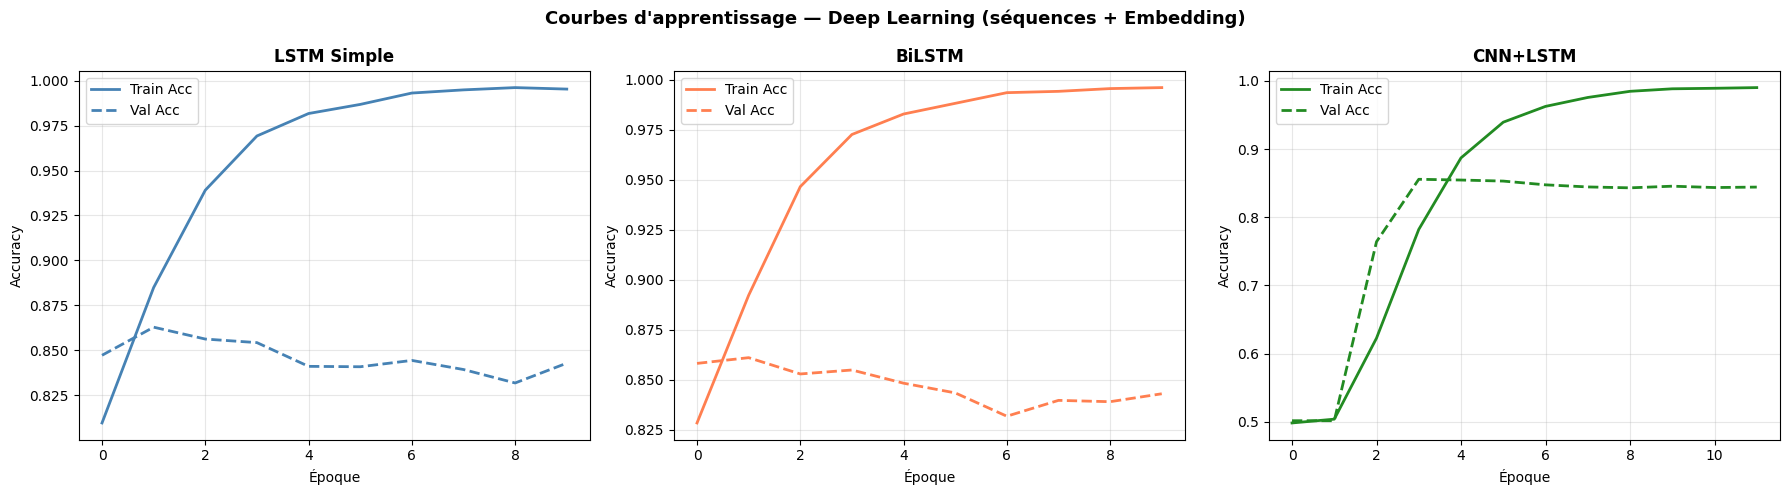

✓ Courbes DL sauvegardées


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dl_hists  = {
    "LSTM Simple": hist_lstm_simple,
    "BiLSTM":      hist_bilstm,
    "CNN+LSTM":    hist_cnn_lstm,
}
colors = ["steelblue", "coral", "forestgreen"]

for ax, (name, hist), c in zip(axes, dl_hists.items(), colors):
    ax.plot(hist.history["accuracy"],     color=c, label="Train Acc", linewidth=2)
    ax.plot(hist.history["val_accuracy"], color=c, label="Val Acc",
            linestyle="--", linewidth=2)
    ax.set_title(f"{name}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Époque"); ax.set_ylabel("Accuracy")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — Deep Learning (séquences + Embedding)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "courbes_dl.png"), dpi=150)
plt.show()
print("✓ Courbes DL sauvegardées")


# 12. Pipeline C – Fine-tuning Transformers
> **Input texte** :
> - `texte_ml` (arabizi converti) → **DarijaBERT** + **AraBERT**
> - `texte_ar_bert` (arabizi gardé) → **DarijaBERT-arabizi**
>
> Les index du split sont les mêmes → comparaison juste


## 12a. DarijaDataset + Fonction Fine-tuning

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

class DarijaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

print("✓ DarijaDataset défini")


✓ DarijaDataset défini


In [ ]:
def fine_tune_transformer(
    model_name,
    train_texts, train_labels,
    val_texts,   val_labels,
    test_texts,  test_labels,
    num_labels=2, epochs=4, lr=2e-5,
    batch_size=16, max_len=128, warmup_ratio=0.1,
):
    print(f"\n{'='*65}\n  FINE-TUNING : {model_name}\n{'='*65}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, ignore_mismatched_sizes=True
    ).to(device)

    train_dl = DataLoader(
        DarijaDataset(train_texts, train_labels, tokenizer, max_len),
        batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(
        DarijaDataset(val_texts,   val_labels,   tokenizer, max_len),
        batch_size=batch_size)
    test_dl  = DataLoader(
        DarijaDataset(test_texts,  test_labels,  tokenizer, max_len),
        batch_size=batch_size)

    optimizer   = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * warmup_ratio),
        num_training_steps=total_steps
    )

    best_f1, best_state = 0.0, None
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    for epoch in range(epochs):
        # ── Train ────────────────────────────────────────────
        model.train(); train_loss = 0.0
        for batch in train_dl:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labs = batch["labels"].to(device)
            out  = model(input_ids=ids, attention_mask=mask, labels=labs)
            loss = out.loss; train_loss += loss.item()
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        # ── Validation ───────────────────────────────────────
        model.eval()
        vp, vt, val_loss = [], [], 0.0
        with torch.no_grad():
            for batch in val_dl:
                ids  = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                labs = batch["labels"].to(device)
                out  = model(input_ids=ids, attention_mask=mask, labels=labs)
                val_loss += out.loss.item()
                vp.extend(out.logits.argmax(-1).cpu().numpy())
                vt.extend(labs.cpu().numpy())

        acc_v = accuracy_score(vt, vp)
        f1_v  = f1_score(vt, vp, average="macro")
        history["train_loss"].append(train_loss / len(train_dl))
        history["val_loss"].append(val_loss / len(val_dl))
        history["val_acc"].append(acc_v); history["val_f1"].append(f1_v)
        print(f"  Epoch {epoch+1}/{epochs} | TrLoss: {train_loss/len(train_dl):.4f}"
              f" | ValLoss: {val_loss/len(val_dl):.4f}"
              f" | ValAcc: {acc_v:.4f} | ValF1: {f1_v:.4f}")
        if f1_v > best_f1:
            best_f1    = f1_v
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # ── Test ─────────────────────────────────────────────────
    model.load_state_dict(best_state); model.eval()
    tp, tt = [], []
    with torch.no_grad():
        for batch in test_dl:
            out = model(input_ids=batch["input_ids"].to(device),
                        attention_mask=batch["attention_mask"].to(device))
            tp.extend(out.logits.argmax(-1).cpu().numpy())
            tt.extend(batch["labels"].numpy())

    acc_t = accuracy_score(tt, tp)
    f1_t  = f1_score(tt, tp, average="macro")
    print(f"\n  ✓ TEST → Acc: {acc_t:.4f}  F1: {f1_t:.4f}")
    print(classification_report(tt, tp, target_names=le.classes_, digits=3))
    return model, tokenizer, history, acc_t, f1_t

print("✓ fine_tune_transformer définie")


✓ fine_tune_transformer définie


## 12b. DarijaBERT — `SI2M-Lab/DarijaBERT`

In [ ]:
# Textes (dans l'ordre du split) : arabizi converti → arabe
texts_all_ml = df["texte_ml"].tolist()
texts_train_ml = [texts_all_ml[i] for i in idx_train]
texts_val_ml   = [texts_all_ml[i] for i in idx_val]
texts_test_ml  = [texts_all_ml[i] for i in idx_test]

model_darija, tok_darija, hist_darija, acc_darija, f1_darija = fine_tune_transformer(
    model_name   = "SI2M-Lab/DarijaBERT",
    train_texts  = texts_train_ml,
    train_labels = y_train.tolist(),
    val_texts    = texts_val_ml,
    val_labels   = y_val.tolist(),
    test_texts   = texts_test_ml,
    test_labels  = y_test.tolist(),
    num_labels=2, epochs=4, lr=2e-5, batch_size=16, max_len=128,
)
resultats["DarijaBERT"] = {"acc_test": acc_darija, "f1_test": f1_darija}

model_darija.save_pretrained(os.path.join(SAVE_PATH, "DarijaBERT_finetuned"))
tok_darija.save_pretrained(os.path.join(SAVE_PATH, "DarijaBERT_finetuned"))
print("✓ DarijaBERT fine-tuné sauvegardé")



  FINE-TUNING : SI2M-Lab/DarijaBERT


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/307 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: SI2M-Lab/DarijaBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

  Epoch 1/4 | TrLoss: 0.3812 | ValLoss: 0.3004 | ValAcc: 0.8681 | ValF1: 0.8681
  Epoch 2/4 | TrLoss: 0.2411 | ValLoss: 0.2880 | ValAcc: 0.8809 | ValF1: 0.8807
  Epoch 3/4 | TrLoss: 0.1572 | ValLoss: 0.4488 | ValAcc: 0.8773 | ValF1: 0.8773
  Epoch 4/4 | TrLoss: 0.1061 | ValLoss: 0.5285 | ValAcc: 0.8773 | ValF1: 0.8773

  ✓ TEST → Acc: 0.8828  F1: 0.8826
              precision    recall  f1-score   support

    Negative      0.854     0.924     0.888      2845
    Positive      0.917     0.841     0.877      2831

    accuracy                          0.883      5676
   macro avg      0.886     0.883     0.883      5676
weighted avg      0.885     0.883     0.883      5676



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ DarijaBERT fine-tuné sauvegardé


## 12c. DarijaBERT-arabizi — `SI2M-Lab/DarijaBERT-arabizi`
> Arabizi gardé en latin (7, 3, 9 non convertis)

In [ ]:
# Textes pour DarijaBERT-arabizi : arabizi GARDÉ (pas converti)
texts_all_arbert = df["texte_ar_bert"].tolist()
texts_train_arbert = [texts_all_arbert[i] for i in idx_train]
texts_val_arbert   = [texts_all_arbert[i] for i in idx_val]
texts_test_arbert  = [texts_all_arbert[i] for i in idx_test]

model_arabizi, tok_arabizi, hist_arabizi, acc_arabizi, f1_arabizi = fine_tune_transformer(
    model_name   = "SI2M-Lab/DarijaBERT-arabizi",
    train_texts  = texts_train_arbert,
    train_labels = y_train.tolist(),
    val_texts    = texts_val_arbert,
    val_labels   = y_val.tolist(),
    test_texts   = texts_test_arbert,
    test_labels  = y_test.tolist(),
    num_labels=2, epochs=4, lr=2e-5, batch_size=16, max_len=128,
)
resultats["DarijaBERT-arabizi"] = {"acc_test": acc_arabizi, "f1_test": f1_arabizi}

model_arabizi.save_pretrained(os.path.join(SAVE_PATH, "DarijaBERT_arabizi_finetuned"))
tok_arabizi.save_pretrained(os.path.join(SAVE_PATH, "DarijaBERT_arabizi_finetuned"))
print("✓ DarijaBERT-arabizi fine-tuné sauvegardé")



  FINE-TUNING : SI2M-Lab/DarijaBERT-arabizi


config.json:   0%|          | 0.00/787 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: SI2M-Lab/DarijaBERT-arabizi
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you 

  Epoch 1/4 | TrLoss: 0.3433 | ValLoss: 0.2936 | ValAcc: 0.8870 | ValF1: 0.8870
  Epoch 2/4 | TrLoss: 0.2009 | ValLoss: 0.3090 | ValAcc: 0.8963 | ValF1: 0.8963
  Epoch 3/4 | TrLoss: 0.1098 | ValLoss: 0.4587 | ValAcc: 0.8998 | ValF1: 0.8997
  Epoch 4/4 | TrLoss: 0.0536 | ValLoss: 0.5980 | ValAcc: 0.8978 | ValF1: 0.8978

  ✓ TEST → Acc: 0.9005  F1: 0.9004
              precision    recall  f1-score   support

    Negative      0.880     0.928     0.903      2845
    Positive      0.923     0.873     0.897      2831

    accuracy                          0.900      5676
   macro avg      0.902     0.900     0.900      5676
weighted avg      0.902     0.900     0.900      5676



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ DarijaBERT-arabizi fine-tuné sauvegardé


## 12d. AraBERT — `aubmindlab/bert-base-arabertv2`

In [ ]:
model_arabert, tok_arabert, hist_arabert, acc_arabert, f1_arabert = fine_tune_transformer(
    model_name   = "aubmindlab/bert-base-arabertv2",
    train_texts  = texts_train_ml,   # arabizi converti → arabe
    train_labels = y_train.tolist(),
    val_texts    = texts_val_ml,
    val_labels   = y_val.tolist(),
    test_texts   = texts_test_ml,
    test_labels  = y_test.tolist(),
    num_labels=2, epochs=4, lr=2e-5, batch_size=16, max_len=128,
)
resultats["AraBERT"] = {"acc_test": acc_arabert, "f1_test": f1_arabert}

model_arabert.save_pretrained(os.path.join(SAVE_PATH, "AraBERT_finetuned"))
tok_arabert.save_pretrained(os.path.join(SAVE_PATH, "AraBERT_finetuned"))
print("✓ AraBERT fine-tuné sauvegardé")



  FINE-TUNING : aubmindlab/bert-base-arabertv2


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider

  Epoch 1/4 | TrLoss: 0.4119 | ValLoss: 0.3935 | ValAcc: 0.8181 | ValF1: 0.8142
  Epoch 2/4 | TrLoss: 0.2923 | ValLoss: 0.3162 | ValAcc: 0.8661 | ValF1: 0.8661
  Epoch 3/4 | TrLoss: 0.2185 | ValLoss: 0.3620 | ValAcc: 0.8646 | ValF1: 0.8645
  Epoch 4/4 | TrLoss: 0.1725 | ValLoss: 0.4390 | ValAcc: 0.8681 | ValF1: 0.8681

  ✓ TEST → Acc: 0.8687  F1: 0.8687
              precision    recall  f1-score   support

    Negative      0.864     0.876     0.870      2845
    Positive      0.874     0.862     0.868      2831

    accuracy                          0.869      5676
   macro avg      0.869     0.869     0.869      5676
weighted avg      0.869     0.869     0.869      5676



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ AraBERT fine-tuné sauvegardé


# 13. Courbes d'Apprentissage — Transformers

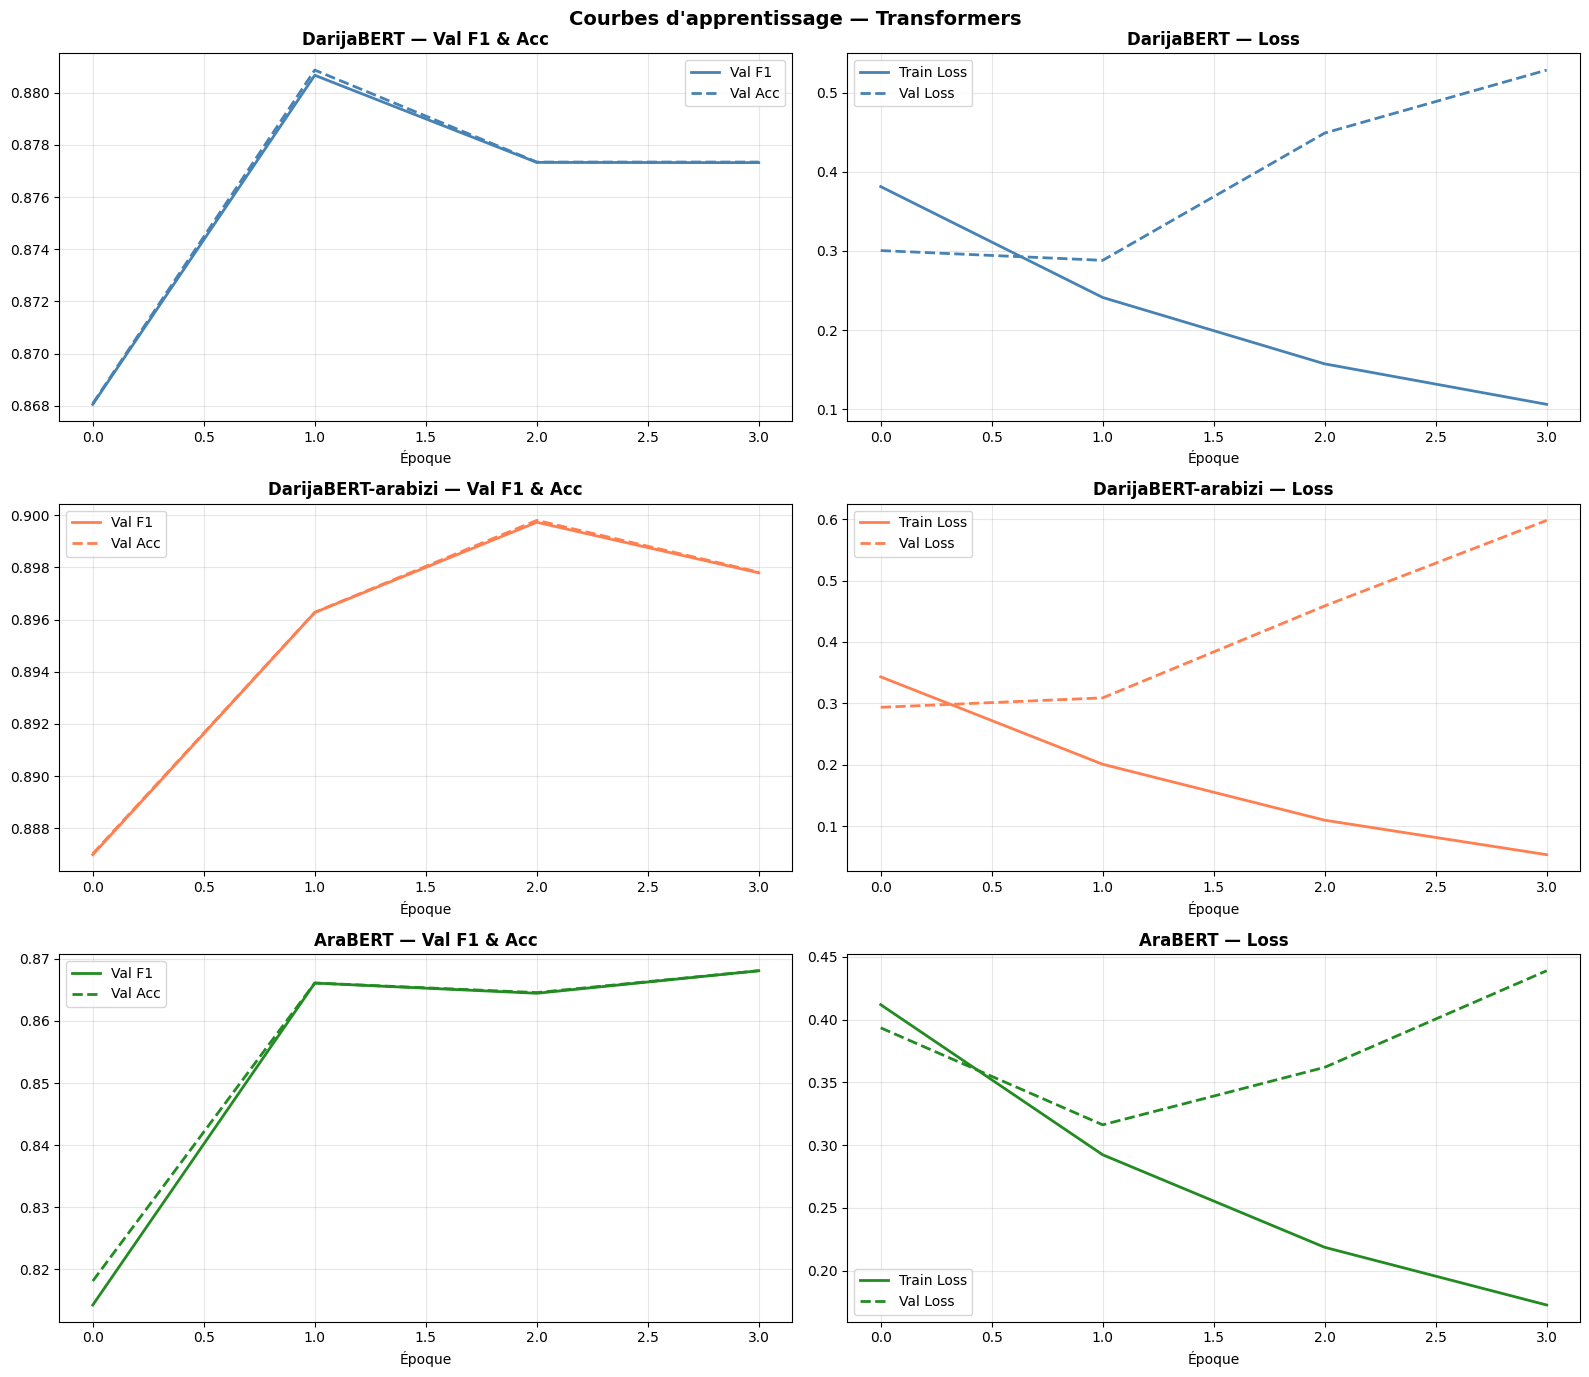

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
tr_histories = {
    "DarijaBERT":         hist_darija,
    "DarijaBERT-arabizi": hist_arabizi,
    "AraBERT":            hist_arabert,
}
colors = ["steelblue", "coral", "forestgreen"]

for row, ((name, hist), c) in enumerate(zip(tr_histories.items(), colors)):
    # F1 + Accuracy
    axes[row, 0].plot(hist["val_f1"],  color=c, linewidth=2, label="Val F1")
    axes[row, 0].plot(hist["val_acc"], color=c, linewidth=2,
                      linestyle="--", label="Val Acc")
    axes[row, 0].set_title(f"{name} — Val F1 & Acc", fontweight="bold")
    axes[row, 0].set_xlabel("Époque"); axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    # Loss
    axes[row, 1].plot(hist["train_loss"], color=c, linewidth=2, label="Train Loss")
    axes[row, 1].plot(hist["val_loss"],   color=c, linewidth=2,
                      linestyle="--", label="Val Loss")
    axes[row, 1].set_title(f"{name} — Loss", fontweight="bold")
    axes[row, 1].set_xlabel("Époque"); axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — Transformers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "courbes_transformers.png"), dpi=150)
plt.show()


# 14. Comparaison Finale — Tous les Modèles

In [ ]:
print("\n" + "="*70)
print("  COMPARAISON FINALE — TEST SET (Positif / Négatif)")
print("="*70)
print(f"  {'Modèle':<25} {'Accuracy':>10} {'F1-macro':>10}  Pipeline")
print("  " + "-"*65)

pipeline_map = {
    "Logistic Regression": "A – ML Classiques (TF-IDF)",
    "LinearSVC":           "A – ML Classiques (TF-IDF)",
    "Naive Bayes":         "A – ML Classiques (TF-IDF)",
    "Random Forest":       "A – ML Classiques (TF-IDF)",
    "LSTM Simple":         "B – DL (Embedding + séquences)",
    "BiLSTM":              "B – DL (Embedding + séquences)",
    "CNN+LSTM":            "B – DL (Embedding + séquences)",
    "DarijaBERT":          "C – Transformer (arabizi→arabe)",
    "DarijaBERT-arabizi":  "C – Transformer (latin arabizi)",
    "AraBERT":             "C – Transformer (arabe)",
}

rows = sorted(resultats.items(), key=lambda x: x[1]["f1_test"], reverse=True)
for nom, scores in rows:
    print(f"  {nom:<25} {scores['acc_test']:>10.4f} {scores['f1_test']:>10.4f}"
          f"  {pipeline_map.get(nom, '')}")

print("=" * 70)
best = rows[0]
print(f"\n🏆 Meilleur modèle : {best[0]}  (F1-macro = {best[1]['f1_test']:.4f})")



  COMPARAISON FINALE — TEST SET (Positif / Négatif)
  Modèle                      Accuracy   F1-macro  Pipeline
  -----------------------------------------------------------------
  DarijaBERT-arabizi            0.9005     0.9004  C – Transformer (latin arabizi)
  DarijaBERT                    0.8828     0.8826  C – Transformer (arabizi→arabe)
  AraBERT                       0.8687     0.8687  C – Transformer (arabe)
  BiLSTM                        0.8640     0.8640  B – DL (Embedding + séquences)
  LSTM Simple                   0.8624     0.8621  B – DL (Embedding + séquences)
  Logistic Regression           0.8539     0.8539  A – ML Classiques (TF-IDF)
  CNN+LSTM                      0.8444     0.8443  B – DL (Embedding + séquences)
  LinearSVC                     0.8414     0.8414  A – ML Classiques (TF-IDF)
  Random Forest                 0.8356     0.8356  A – ML Classiques (TF-IDF)
  Naive Bayes                   0.7912     0.7912  A – ML Classiques (TF-IDF)

🏆 Meilleur modèle :

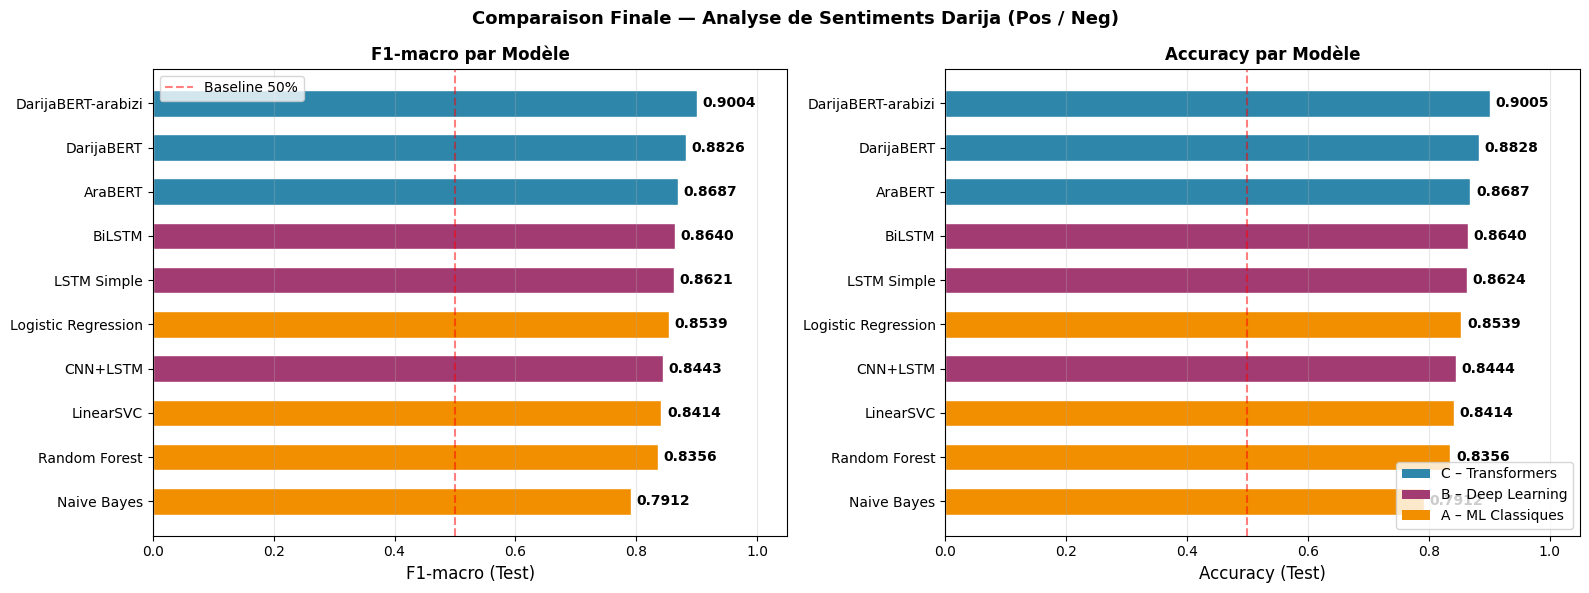

✓ Graphique sauvegardé


In [ ]:
# ── Graphique barre horizontale ───────────────────────────────────────────────
noms = [r[0] for r in rows]
f1s  = [r[1]["f1_test"] for r in rows]
accs = [r[1]["acc_test"] for r in rows]

color_map = []
for n in noms:
    if "BERT" in n or "araBERT" in n.lower(): color_map.append("#2E86AB")
    elif n in ["LSTM Simple", "BiLSTM", "CNN+LSTM"]: color_map.append("#A23B72")
    else: color_map.append("#F18F01")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1-macro
bars1 = axes[0].barh(noms[::-1], f1s[::-1],
                      color=color_map[::-1], edgecolor="white", height=0.6)
axes[0].bar_label(bars1, fmt="%.4f", padding=4, fontsize=10, fontweight="bold")
axes[0].set_xlabel("F1-macro (Test)", fontsize=12)
axes[0].set_title("F1-macro par Modèle", fontweight="bold", fontsize=12)
axes[0].axvline(x=0.5, color="red", linestyle="--", alpha=0.5, label="Baseline 50%")
axes[0].legend(); axes[0].grid(axis="x", alpha=0.3); axes[0].set_xlim(0, 1.05)

# Accuracy
bars2 = axes[1].barh(noms[::-1], accs[::-1],
                      color=color_map[::-1], edgecolor="white", height=0.6)
axes[1].bar_label(bars2, fmt="%.4f", padding=4, fontsize=10, fontweight="bold")
axes[1].set_xlabel("Accuracy (Test)", fontsize=12)
axes[1].set_title("Accuracy par Modèle", fontweight="bold", fontsize=12)
axes[1].axvline(x=0.5, color="red", linestyle="--", alpha=0.5)
axes[1].grid(axis="x", alpha=0.3); axes[1].set_xlim(0, 1.05)

# Légende pipeline
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2E86AB", label="C – Transformers"),
    Patch(facecolor="#A23B72", label="B – Deep Learning"),
    Patch(facecolor="#F18F01", label="A – ML Classiques"),
]
axes[1].legend(handles=legend_elements, loc="lower right")

plt.suptitle("Comparaison Finale — Analyse de Sentiments Darija (Pos / Neg)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "comparaison_finale.png"), dpi=150)
plt.show()
print("✓ Graphique sauvegardé")
